### Phase vs. amplitude encoding in the Hopf (Stuart–Landau) model

This notebook reproduces **Figure 3** by simulating two Stuart–Landau (Hopf) oscillators coupled via a transient unidirectional link and quantifying how much stimulus-related information is carried by the joint amplitude A vs. the phase difference Δθ.

**Workflow:**
1. Configure environment and imports.
2. Define simulation parameters and the coupling profile.
3. Run the vectorised simulation across all trials.
4. Extract A and Δθ from the analytic signal; compute GC-MI.
5. Decompose joint MI into redundancy, synergy and unique information (PID).
6. Assemble and export the figure.

#### 1) Environment setup

Add the project root to `sys.path` so `src.models.simulate` is importable. Force JAX to CPU to avoid GPU memory contention during the large vectorised simulation.

In [19]:
import os
from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd().parent))

In [20]:
from functools import partial

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from frites.core import copnorm_nd
from hoi.core import get_mi
from mne.filter import filter_data
from mne.time_frequency import tfr_array_morlet, tfr_array_multitaper
from tqdm import tqdm

from src.models import simulate

#### 2) Imports and matplotlib style

In [21]:
jax.config.update("jax_platform_name", "cpu")

In [22]:
SMALL_SIZE = 8
MEDIUM_SIZE = 9
BIGGER_SIZE = 10

plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=SMALL_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)  # fontsize of the figure title

#### 3) Simulation parameters

Two Stuart–Landau nodes (Hopf normal form): bifurcation parameter a = −5 (stable limit-cycle regime), ω = 2π × 40 Hz, noise β = 10⁻⁴. The simulation runs at 10 kHz and is decimated by 20 → 500 Hz effective sampling rate. Coupling is unidirectional: node 0 drives node 1.

In [23]:
Nareas = 2
ntrials = 1000
fsamp = 1 / 1e-4          # The SLM model required high fs = 10 kHz

time = np.arange(-4, 2, 1 / fsamp)
beta = 1e-4
Npoints = len(time)
decim = 20                 # downsample 10 kHz → 500 Hz

C = np.array([[0, 1], [0, 0]]).T  # C[j,i]=1: node i drives node j  (0→1)

f = 40  # Hz, natural frequency of both nodes

In [24]:
s = 8 / (2 * np.pi * f)

time_start = 0
time_end = 0.4
timestim = time[(time > time_start) & (time < time_end)] - (time_end - time_start) / 2
ind = np.where((time > time_start) & (time < time_end))[0]
gaussian = np.exp(-(timestim**2) / (2 * s**2))
coupling = np.zeros_like(time)
coupling[ind] = gaussian

# Coupling strength array (linearly spaced from 1 to 100)
CS = np.linspace(1, 100, ntrials)
seeds = np.random.randint(0, 100000, ntrials)

#### 4) Vectorised simulation across trials

`jax.vmap` maps `simulate` over the trial axis of `coupling` (shape `ntrials × T`) and `seeds`, running all 1000 trials in a single JIT-compiled pass.

In [25]:
# vmap over trial axis: in_axes maps coupling (axis 0 = trials) and seeds (axis 0)
simulate_loop = jax.vmap(
    simulate, in_axes=(None, 0, None, None, None, None, None, None, 0, None, None)
)

In [26]:
# outer product: shape (ntrials, T) — each trial gets its own coupling amplitude
coupling = CS[:, None] * coupling

In [ ]:
out = simulate_loop(
    1 * C,
    coupling,
    40,
    -5,
    fsamp,
    beta,
    Npoints,
    None,
    seeds,
    "cpu",
    decim,
)

In [28]:
data = xr.DataArray(
    np.stack(out),
    dims=("trials", "roi", "times"),
    coords=(range(ntrials), ["x", "y"], time[::decim]),
).sel(times=slice(-0.5, 1))

#### 5) Amplitude, phase-difference and mutual information

The cross-spectrum `z = x · y*` encodes both amplitude synchrony and phase-locking. Its modulus A and argument Δθ are used as separate or joint predictors of the stimulus Y via GC-MI vmapped over time.

In [29]:
mi_fcn = get_mi("gc")
mi_fcn_time = jax.vmap(mi_fcn, in_axes=(2, 2, None, None))

(-0.25, 1.0)

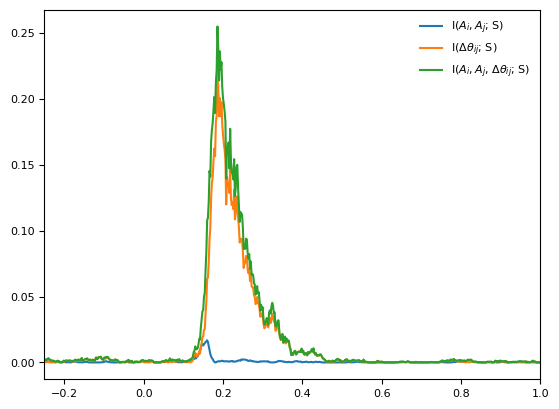

In [30]:
z = data[:, 0] * np.conj(data[:, 1])   # cross-spectrum: encodes amplitude and phase jointly

A    = np.abs(z).values                  # joint amplitude (envelope product)
dphi = np.angle(z)
dphi = np.abs((dphi + np.pi) % (2 * np.pi) - np.pi)  # wrapped to [0, π]

labels = np.tile(np.expand_dims(np.linspace(0, 100, ntrials), 1), dphi.shape[1])

I_S_R1 = mi_fcn_time(A[None], labels[None], False, True)
plt.plot(data.times, I_S_R1)

I_S_R2 = mi_fcn_time(dphi[None], labels[None], False, True)
plt.plot(data.times, I_S_R2)

# multivariate: stack A and dphi → (2, ntrials, times) for joint MI
I_S_R1_R2 = mi_fcn_time(np.stack((A, dphi)), labels[None], False, True)
plt.plot(data.times, I_S_R1_R2)

plt.legend(
    [
        r"I($A_{i}, A_{j}$; S)",
        r"I($\Delta\theta_{ij}$; S)",
        r"I($A_{i}, A_{j}$, $\Delta\theta_{ij}$; S)",
    ],
    frameon=False,
)

plt.xlim(-0.25, 1)

#### 6) PID — redundancy, synergy and unique information

- **Redundancy** R = min(I(A;Y), I(Δθ;Y)) — information shared by both predictors.
- **Synergy** S = I(A,Δθ;Y) − max(I(A;Y), I(Δθ;Y)) — extra information from the joint variable.
- **Unique** U(A) = I(A;Y) − R; U(Δθ) = I(Δθ;Y) − R — information exclusive to each predictor.

In [31]:
red = np.minimum(I_S_R2, I_S_R1)
syn = I_S_R1_R2 - np.maximum(I_S_R2, I_S_R1)

(-0.25, 1.0)

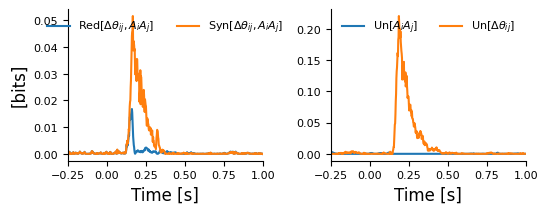

In [32]:
plt.figure(figsize=(15 / 2.54, 5 / 2.54))

ax = plt.subplot(121)
plt.plot(data.times, red)
plt.plot(data.times, syn)

plt.legend(
    [r"Red[$\Delta\theta_{ij}, A_{i}A_{j}$]", r"Syn[$\Delta\theta_{ij}, A_{i}A_{j}$]"],
    frameon=False,
    loc="upper center",
    ncol=2,
)
plt.xlim(-1, 1)
# plt.ylim(-0.0001, 0.01)
[ax.spines[key].set_visible(False) for key in ["top", "right"]]
plt.xlabel("Time [s]", fontsize=12)
plt.ylabel("[bits]", fontsize=12)
plt.xlim(-0.25, 1)


ax = plt.subplot(122)
plt.plot(data.times, I_S_R1 - red)
plt.plot(data.times, I_S_R2 - red)
# plt.ylim(-0.0001, 0.004)
# ax.set_yticklabels([])
plt.legend(
    [r"Un[$A_{i}A_{j}$]", r"Un[$\Delta\theta_{ij}$]"],
    frameon=False,
    loc="upper center",
    ncol=2,
)
[ax.spines[key].set_visible(False) for key in ["top", "right"]]


plt.subplots_adjust(wspace=0.35)
plt.xlabel("Time [s]", fontsize=12)
plt.xlim(-0.25, 1)

#### 7) Figure assembly and export

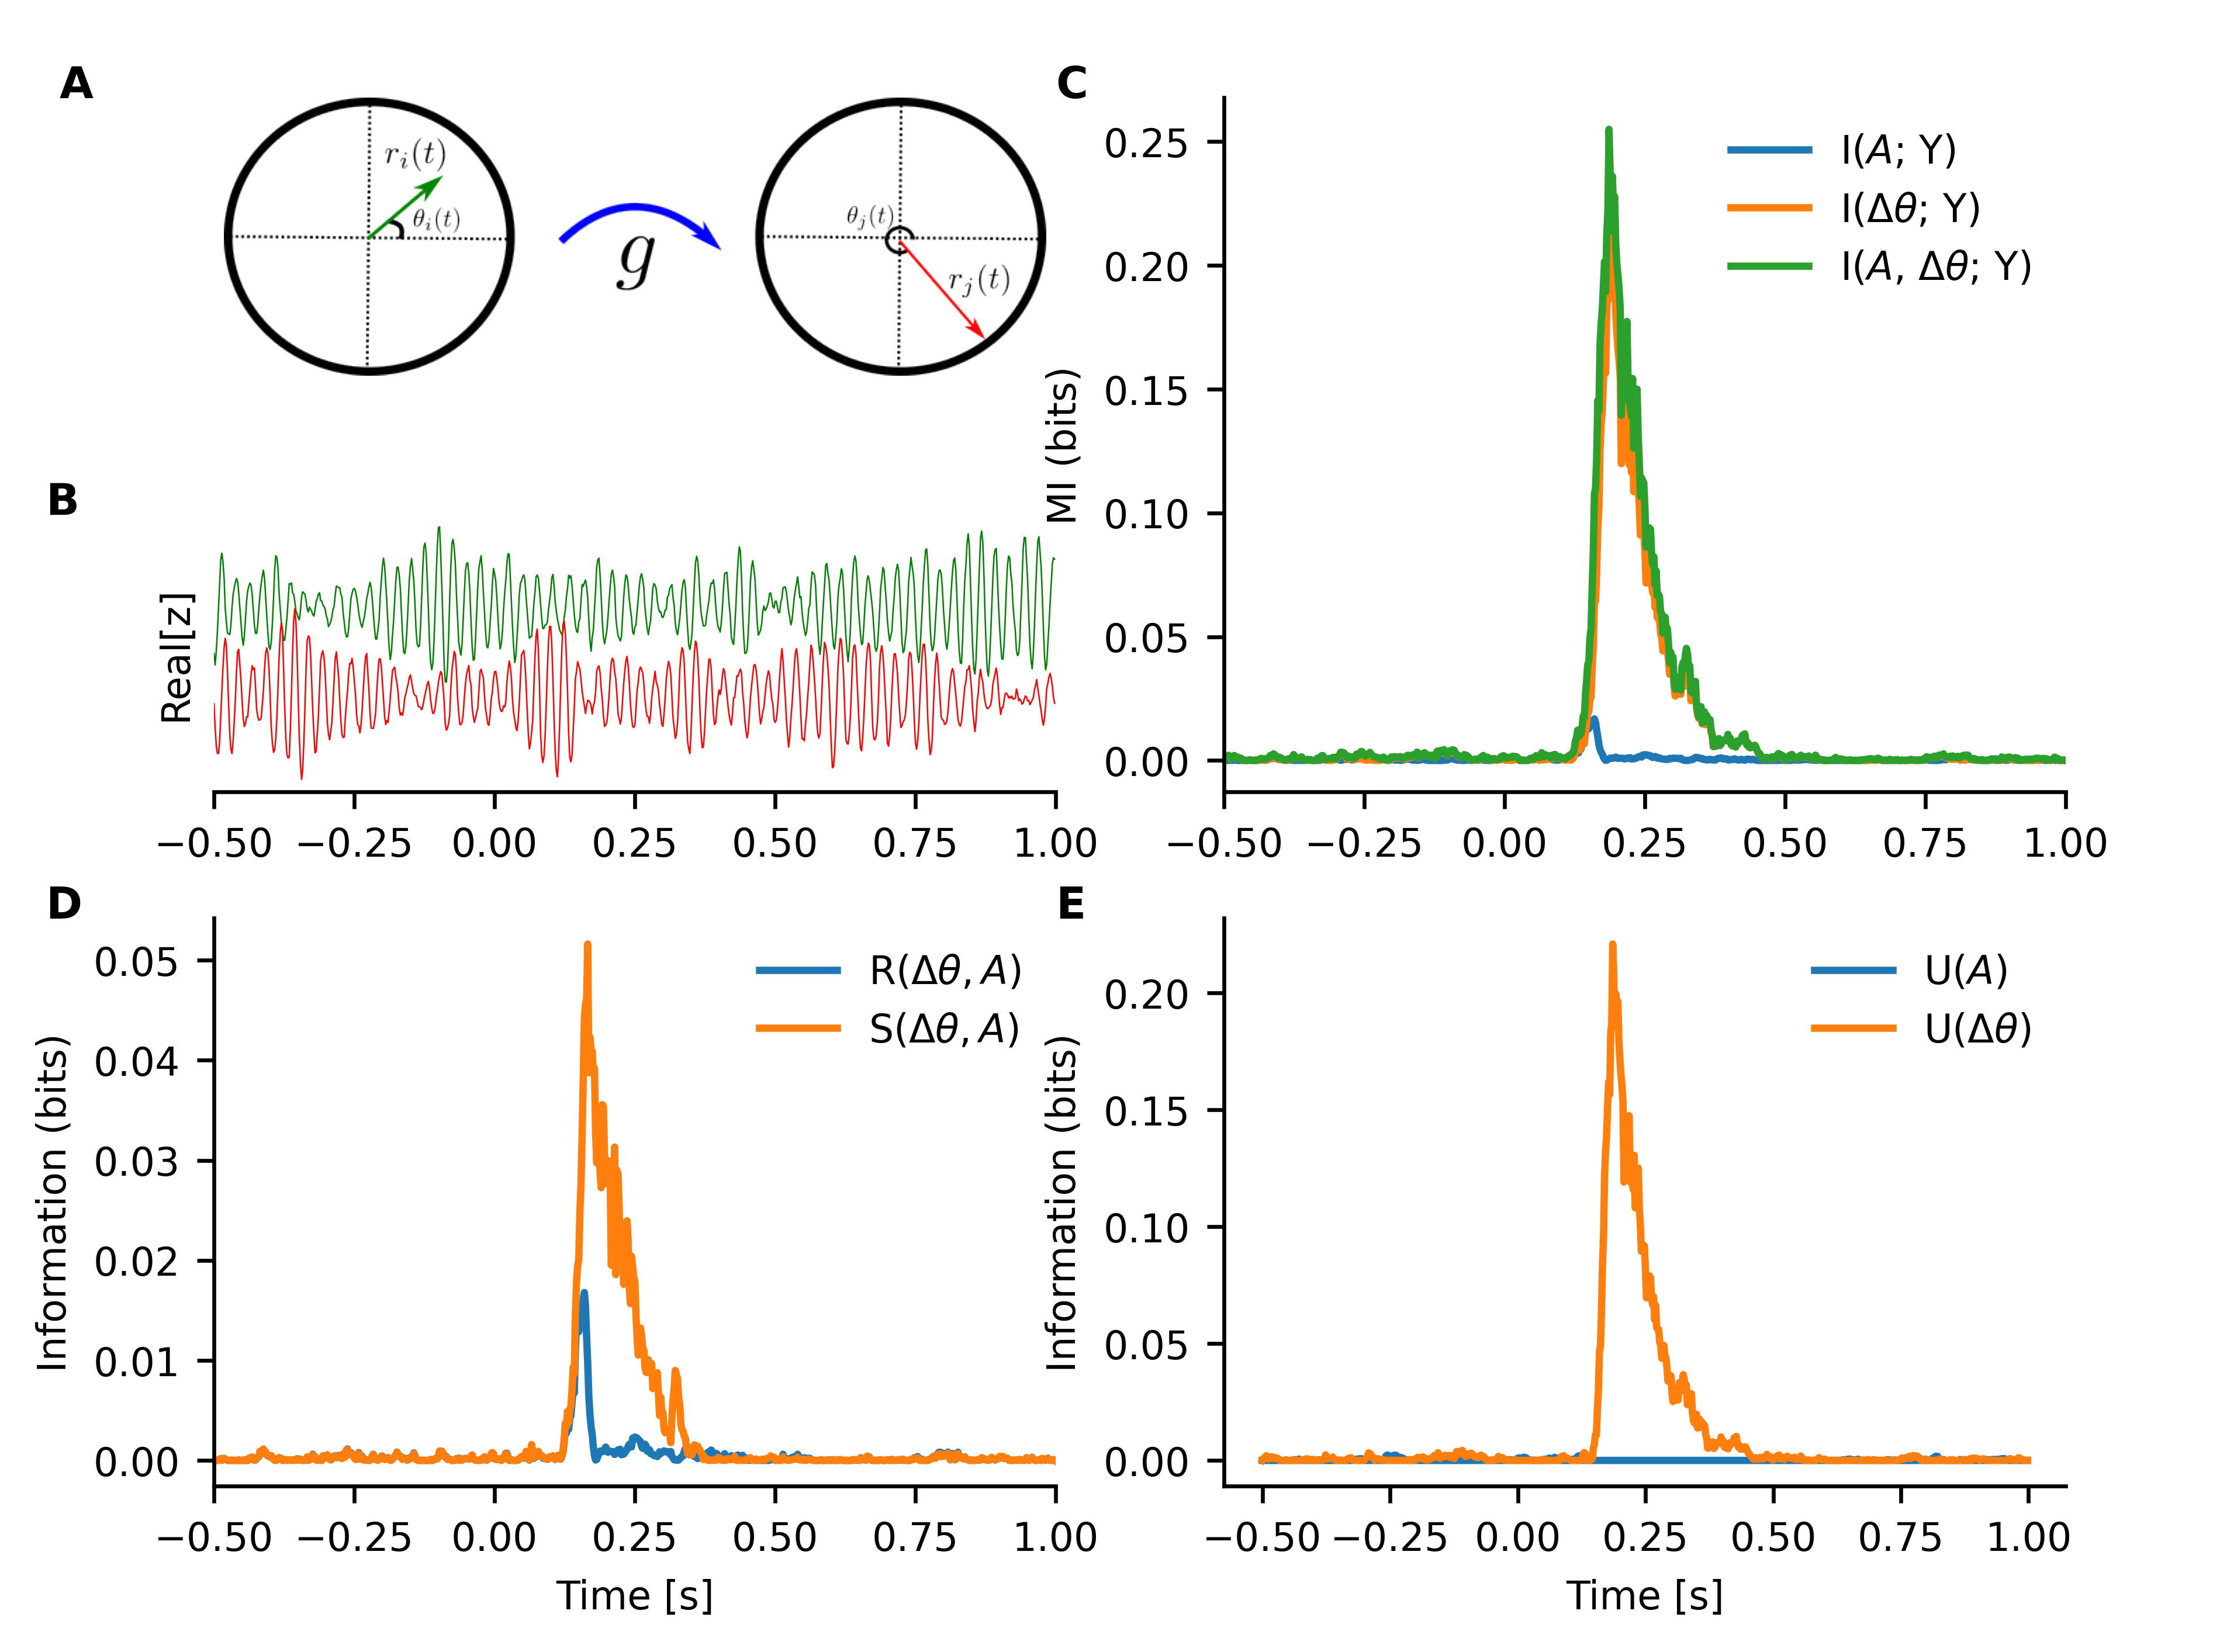

In [36]:
import plot
from PIL import Image

fig = plt.figure(figsize=(6.0, 4.5), dpi=600)

# Two-column layout equally distributed around the figure centre (0.50)
# Col 1 (left):  left=0.06, right=0.46  (centre = 0.26)
# Col 2 (right): left=0.54, right=0.94  (centre = 0.74)
# Both columns are 0.40 wide with a 0.08 gap; symmetric about 0.50.
#
# gs3 wspace = gap / col_width = 0.08 / 0.40 = 0.20  → D/E align exactly with col 1 / col 2.

gs1 = fig.add_gridspec(nrows=2, ncols=1, left=0.06, right=0.46,
                       bottom=0.52, top=0.96, hspace=0.5)
gs2 = fig.add_gridspec(nrows=1, ncols=1, left=0.54, right=0.94,
                       bottom=0.52, top=0.96)
gs3 = fig.add_gridspec(nrows=1, ncols=2, left=0.06, right=0.94,
                       bottom=0.08, top=0.44, wspace=0.20)

# Panel A (cartoon), B (time series) — left column, top row
ax1 = plt.subplot(gs1[0])
ax2 = plt.subplot(gs1[1])

# Panel C (MI) — right column, top row; top and bottom align with A+B
ax3 = plt.subplot(gs2[0])

# Panel D (redundancy/synergy), E (unique) — bottom row
ax4 = plt.subplot(gs3[0])
ax5 = plt.subplot(gs3[1])

###################################### DRAWING ######################################
# PANEL A
plt.sca(ax1)
im = Image.open("../figures/hopf_cartoon.png")
plt.imshow(im)
plt.axis("off")

# PANEL B
plt.sca(ax2)
x, y = data[-1].real
x = (x - x.mean("times")) / x.std("times") + 3
y = (y - y.mean("times")) / y.std("times")

plt.plot(x.times, x, lw=0.3, c="g")
plt.plot(y.times, y, lw=0.3, c="r")
plt.ylabel("Real[z]")
plt.yticks([])
[ax2.spines[key].set_visible(False) for key in ["top", "right", "left"]]
plt.xlim(-0.5, 1)


# PANEL C
plt.sca(ax3)
plt.plot(data.times, I_S_R1)
plt.plot(data.times, I_S_R2)
plt.plot(data.times, I_S_R1_R2)
plt.xlim(-0.5, 1)
plt.legend(
    [r"I($A$; Y)", r"I($\Delta\theta$; Y)", r"I($A$, $\Delta\theta$; Y)"],
    frameon=False,
)
plt.ylabel("MI (bits)")
[ax3.spines[key].set_visible(False) for key in ["top", "right"]]

# PANEL D
plt.sca(ax4)
plt.plot(data.times, red)
plt.plot(data.times, syn)
plt.legend(
    [r"R($\Delta\theta, A$)", r"S($\Delta\theta, A$)"],
    frameon=False,
)
[ax4.spines[key].set_visible(False) for key in ["top", "right"]]
plt.xlabel("Time [s]")
plt.ylabel("Information (bits)")
plt.xlim(-0.5, 1)

# PANEL E
plt.sca(ax5)
plt.plot(data.times, np.clip(I_S_R1 - red, -10000, np.inf))
plt.plot(data.times, np.clip(I_S_R2 - red, -1000, np.inf))
plt.legend(
    [r"U($A$)", r"U($\Delta\theta$)"],
    frameon=False,
)
[ax5.spines[key].set_visible(False) for key in ["top", "right"]]
plt.xlabel("Time [s]")
plt.ylabel("Information (bits)")

bg = plot.Background(visible=False)
plot.add_panel_letters(
    fig,
    axes=[ax1, ax2, ax3, ax4, ax5],
    fontsize=MEDIUM_SIZE,
    xpos=[-0.2] * 5,
    ypos=[1.0] * 5,
)

plt.savefig("../figures/Figure3.pdf")

Figure 3: Phase vs. amplitude encoding encoding in the Hopf model. (A) Simulation of two Stuart-Landau
oscillators (See Eq. 18; using the same parameters for both nodes a = −5; ω = 2π40 Hz; η = 0.0001;
and coupling strength C12 = 1) coupled via a unidirectional link from Xi to Xj. The coupling strength g
among nodes was transiently modulated from 0 to 0.4 ms according to g(t) = 8Y/(2π f ), where Y was the
maximum coupling amplitude which was increased from 1 to 100 across trials (n = 5000). (B) Real part of
the (Real(Z)) time-series for the simulated SL system. (C) Stimulus-related information contained in the
broadband joint-amplitude (blue; A = abs(Zi Z∗
j )); the phase-difference (orange; ∆θ = arg(Zi Z∗
j )), and both
(green). (D) The redundant (blue) and synergistic (green) information between the phase-difference and the
joint-amplitude carried about the stimulus. (E) The unique information carried about the stimulus by the
phase-difference (orange) and the joint-amplitude (blue). 